#標註前置作業:       
#下載label-master.zip 解壓縮並放在與這個ipynb同目錄下，並用vscode開啟這個資料夾            
#把帶有標註圖片的trainimg資料夾放在label-master資料夾中      
#Ctrl+`開啟終端機(切cmd)     
cd labelImg-master #確保在這個資料夾才能進行    
#建立環境並激活      
conda create -n label python=3.9.13 -y     
conda activate label  
#安裝套件 :      
conda install pyqt=5 -y           
pyrcc5 -o libs/resources.py resources.qrc  

#標註作業:       
#Ctrl+`開啟終端機(切cmd)        
cd labelImg-master #確保在這個資料夾才能進行        
conda activate label     
python labelImg.py ./trainimg ./trainimg/classes.txt    
python ./labelImg-master/labelImg.py roboflow_側拍_2/色階排序 roboflow_側拍_2/classes.txt
#把格式切換成yolo(以.txt為標註檔)，(打開檢視)開啟自動儲存模式，按下W開啟框選十字，A/D切換前後張      

成功讀取 3 個類別: ['level_1', 'level_2', 'level_3']

🎨 類別顏色對應表：
level_1 → green
level_2 → white
level_3 → red

📊 類別統計與比例：
level_1: 3419 (46.02%)
level_2: 1595 (21.47%)
level_3: 2416 (32.52%)

🎲 抽樣顯示...
💡 啟用分段抽樣：每 100 張抽 1 張
   總圖片數: 1200, 預計抽檢: 12 張


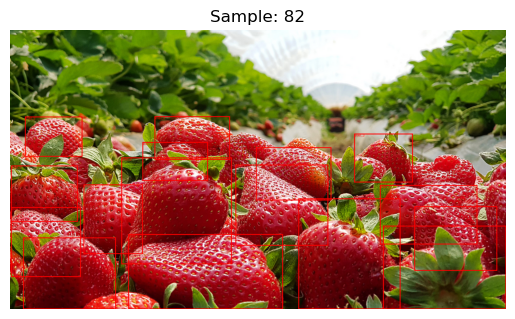

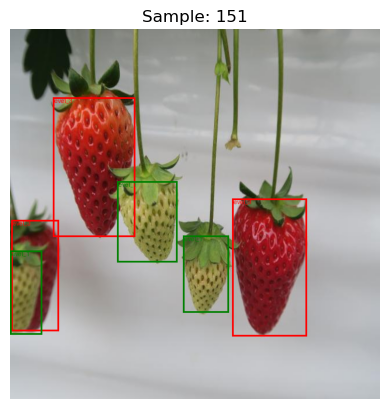

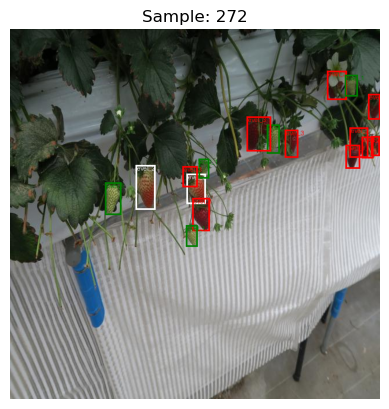

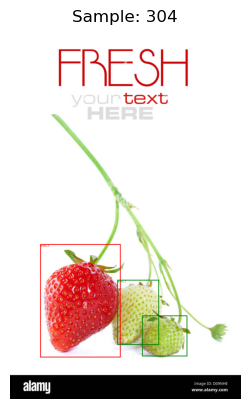

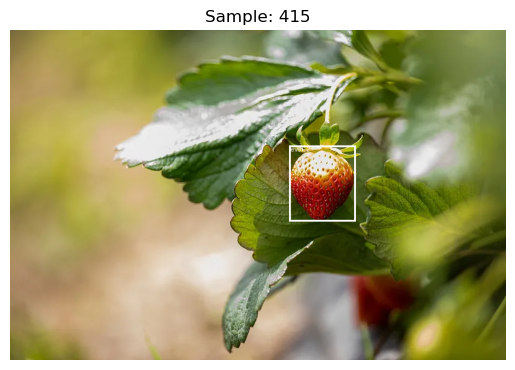

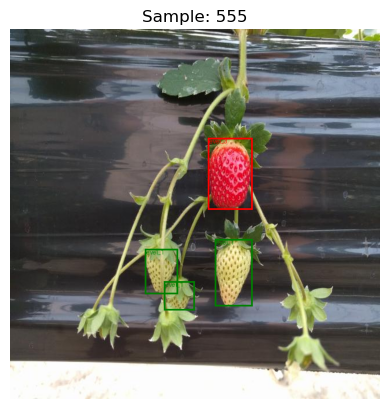

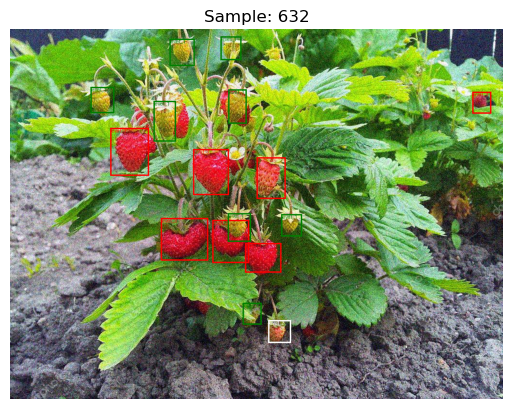

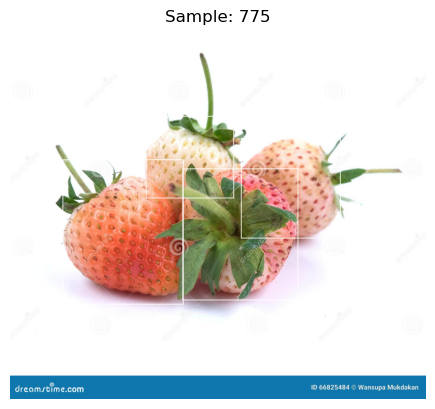

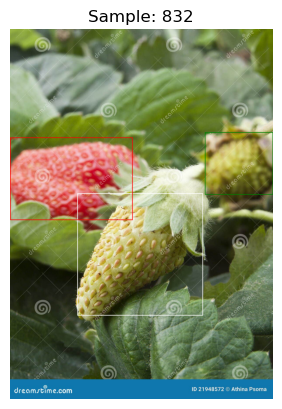

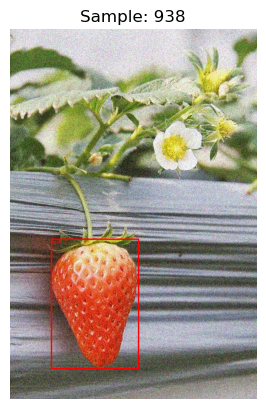

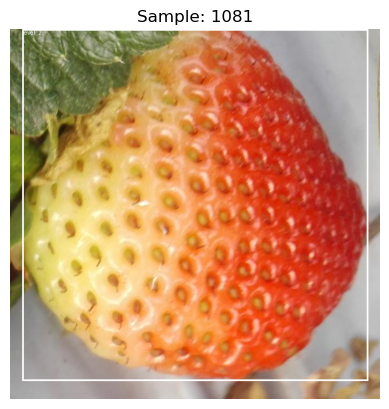

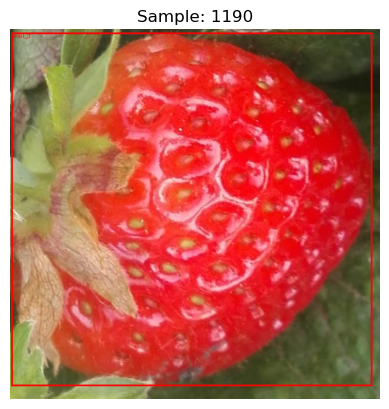

In [14]:
#多組DATA_DIR
# DATA_DIR = './roboflow_1000_側拍'
# DATA_DIR = './roboflow_側拍'
# DATA_DIR = './labelImg-master/trainimg' 
# DATA_DIR = './roboflow_俯拍_2'
# DATA_DIR = './roboflow_側拍_2'
#roboflow_側拍_2/色階排序 roboflow_側拍_2/單顆草莓 roboflow_側拍_2/綜合
import os
import random
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib


# 讓 VSCode inline 顯示
matplotlib.use('module://matplotlib_inline.backend_inline')

# --- 腳本設定 ---
#當前資料夾目錄
#C:\Users\0419mch\Desktop\project_0414
DATA_DIR = './labelImg-master/trainimg'  # 📁 你的資料夾（改成你的路徑）
CLASSES_FILE = './labelImg-master/trainimg/classes.txt'

# --- 抽樣設定 ---
USE_STRATIFIED_SAMPLING = True  # 是否啟用「每 N 張抽 M 張」的模式 (True: 指定比例, False: 全體隨機抽 3 張)
EVERY_N_IMAGES = 100            # 每隔多少張圖片 (例如 1~100, 101~200...)
SAMPLE_M_IMAGES = 1             # 抽取多少張檢查

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

# 🎨 顏色池（會自動分配）
COLOR_POOL = [
    "green", "white","red"
]

image_size_cache = {}

def get_image_size(base_name):
    for ext in IMAGE_EXTENSIONS:
        path = os.path.join(DATA_DIR, base_name + ext)
        if os.path.exists(path):
            if path not in image_size_cache:
                try:
                    with Image.open(path) as img:
                        image_size_cache[path] = img.size
                except:
                    return None
            return image_size_cache[path]
    return None




def get_image_path(base_name):
    for ext in IMAGE_EXTENSIONS:
        path = os.path.join(DATA_DIR, base_name + ext)
        if os.path.exists(path):
            return path
    return None


# 🎨 建立 class → color 對應
def build_color_map(class_names):
    color_map = {}
    for i, name in enumerate(class_names):
        color_map[i] = COLOR_POOL[i % len(COLOR_POOL)]
    return color_map


# 🧪 畫 bbox + 顏色
def draw_bbox(image_path, label_path, class_names, color_map):
    img = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    w, h = img.size

    with open(label_path, 'r') as f:
        lines = [line.strip() for line in f if line.strip()]

    for line in lines:
        parts = line.split()
        if len(parts) < 5:
            continue

        cls_id = int(parts[0])
        x, y, bw, bh = map(float, parts[1:5])

        x1 = int((x - bw/2) * w)
        y1 = int((y - bh/2) * h)
        x2 = int((x + bw/2) * w)
        y2 = int((y + bh/2) * h)

        color = color_map.get(cls_id, "white")

        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

        if 0 <= cls_id < len(class_names):
            text = class_names[cls_id]
            draw.text((x1, y1), text, fill=color)

    return img


def analyze_labels_with_bbox_check():
    try:
        with open(CLASSES_FILE, 'r', encoding='utf-8') as f:
            class_names = [line.strip() for line in f if line.strip()]
        print(f"成功讀取 {len(class_names)} 個類別: {class_names}")
    except Exception as e:
        print(f"讀取類別檔案失敗: {e}")
        return

    # 🎨 建立顏色對應
    color_map = build_color_map(class_names)

    print("\n🎨 類別顏色對應表：")
    print("=" * 30)
    for i, name in enumerate(class_names):
        print(f"{name} → {color_map[i]}")
    print("=" * 30)

    total_images = set()
    annotated_images = set()
    
    class_counts = [0] * len(class_names)  # 🟢 初始化類別計數

    for filename in os.listdir(DATA_DIR):
        base, ext = os.path.splitext(filename)
        ext = ext.lower()

        if ext in IMAGE_EXTENSIONS:
            total_images.add(base)

        if ext == '.txt':
            if base != 'classes': # 排除 classes.txt
                annotated_images.add(base)
                # 🟢 統計每個類別
                try:
                    with open(os.path.join(DATA_DIR, filename), 'r', encoding='utf-8') as f:
                        lines = [line.strip() for line in f if line.strip()]
                    for line in lines:
                        parts = line.split()
                        if len(parts) >= 1:
                            cls_id = int(parts[0])
                            if 0 <= cls_id < len(class_counts):
                                class_counts[cls_id] += 1
                except:
                    pass

    # 🟢 類別比例統計
    total_labels = sum(class_counts)
    print("\n📊 類別統計與比例：")
    print("=" * 30)
    for i, count in enumerate(class_counts):
        pct = (count / total_labels * 100) if total_labels > 0 else 0
        print(f"{class_names[i]}: {count} ({pct:.2f}%)")
    print("=" * 30)

    # 🎲 抽樣
    print("\n🎲 抽樣顯示...")
    # 這裡使用自然排序，確保 1-100 的邏輯正確
    valid_samples = sorted(list(annotated_images.intersection(total_images)), key=lambda x: int(x) if x.isdigit() else x)
    
    if len(valid_samples) == 0:
        print("⚠️ 沒有可用圖片")
        return

    selected_samples = []
    if USE_STRATIFIED_SAMPLING:
        # 每 N 張抽 M 張 (邏輯: 1~100 抽一張, 101~200 抽一張...)
        for i in range(0, len(valid_samples), EVERY_N_IMAGES):
            chunk = valid_samples[i : i + EVERY_N_IMAGES]
            num_to_sample = min(SAMPLE_M_IMAGES, len(chunk))
            selected_samples.extend(random.sample(chunk, num_to_sample))
        print(f"💡 啟用分段抽樣：每 {EVERY_N_IMAGES} 張抽 {SAMPLE_M_IMAGES} 張")
        print(f"   總圖片數: {len(valid_samples)}, 預計抽檢: {len(selected_samples)} 張")
    else:
        # 傳統隨機抽 3 張
        num_to_sample = min(3, len(valid_samples))
        selected_samples = random.sample(valid_samples, num_to_sample)
        print(f"💡 啟用一般隨機抽樣：選出 {num_to_sample} 張")

    for base in selected_samples:
        img_path = get_image_path(base)
        label_path = os.path.join(DATA_DIR, base + ".txt")

        if img_path and os.path.exists(label_path):
            img = draw_bbox(img_path, label_path, class_names, color_map)

            # 🖥️ inline 顯示
            plt.figure()
            plt.imshow(img)
            plt.title(f"Sample: {base}")
            plt.axis("off")
            plt.show()

if __name__ == "__main__":
    analyze_labels_with_bbox_check()


In [13]:
# 直接打開指定圖片到 labelImg 進行標註修改
import os
import sys
import subprocess

# --- 路徑設定 ---
LABELIMG_DIR = './labelImg-master'
LABELIMG_PY = os.path.join(LABELIMG_DIR, 'labelImg.py')
IMAGE_DIR = './labelImg-master/trainimg'
CLASSES_FILE = os.path.join(IMAGE_DIR, 'classes.txt')

# --- 你只要改這裡 ---
TARGET_IMAGE_NAME = '1089'  # 不含副檔名，例如 1013
# TARGET_IMAGE_PATH = r'D:\\path\\to\\your\\image.jpg'  # 也可以直接填完整路徑


def find_image_path(image_name_or_path):
    if os.path.isabs(image_name_or_path) and os.path.exists(image_name_or_path):
        return image_name_or_path

    if os.path.exists(image_name_or_path):
        return os.path.abspath(image_name_or_path)

    exts = ['.jpg', '.jpeg', '.png', '.bmp', '.webp']
    for ext in exts:
        candidate = os.path.join(IMAGE_DIR, image_name_or_path + ext)
        if os.path.exists(candidate):
            return os.path.abspath(candidate)

    return None


def open_labelimg(image_name_or_path):
    image_path = find_image_path(image_name_or_path)
    if not image_path:
        print(f'❌ 找不到圖片: {image_name_or_path}')
        return

    classes_path = os.path.abspath(CLASSES_FILE)
    labelimg_path = os.path.abspath(LABELIMG_PY)
    labelimg_dir = os.path.abspath(LABELIMG_DIR)

    if not os.path.exists(labelimg_path):
        print(f'❌ 找不到 labelImg 主程式: {labelimg_path}')
        return

    cmd = [sys.executable, labelimg_path, image_path, classes_path]
    print(f'🚀 開啟 labelImg: {image_path}')

    try:
        subprocess.Popen(cmd, cwd=labelimg_dir)
    except Exception as e:
        print(f'❌ 開啟失敗: {e}')


open_labelimg(TARGET_IMAGE_NAME)


🚀 開啟 labelImg: d:\銘澄專區\畢業專題工作區\labelImg-master\trainimg\1089.jpg


In [ ]:
# 整理檔案名稱
import os
import shutil

# --- 設定變數 ---
# *** 請確認此路徑設定正確！ ***
folder_path = 'roboflow_側拍/單顆草莓' # 這裡請填入你的資料夾路徑
# folder_path = './' # 如果你希望保持原樣，可以使用這個

# 設定起始編號
START_INDEX_LABELED = 1013
START_INDEX_UNLABELED = 10001

# 設定副檔名
IMAGE_EXT = '.jpg'
LABEL_EXT = '.txt'
PAD_LENGTH = 0 # 用於零填充，確保數字排序正確
# --------------------------------

# --- 新增：設定臨時資料夾 ---
TEMP_FOLDER_NAME = 'temp_renamed_output'
temp_path = os.path.join(folder_path, TEMP_FOLDER_NAME)
print(f"將在 '{temp_path}' 中暫存新檔案以避免衝突。")
os.makedirs(temp_path, exist_ok=True)
# --------------------------------

print(f"正在處理資料夾: {os.path.abspath(folder_path)}")

# 1. 取得所有檔案名稱
try:
    all_files = os.listdir(folder_path)
except FileNotFoundError:
    print(f"錯誤：找不到資料夾路徑 '{folder_path}'，請檢查路徑是否正確。")
    raise

# 2. 分類檔案
labeled_stems = set()
unlabeled_image_files = [] 

# 【重要修正】排除資料集中常見的非標註TXT檔案 (例如 classes.txt)
EXCLUDE_FILES = ['classes.txt']
label_files = {f for f in all_files if f.endswith(LABEL_EXT) and f not in EXCLUDE_FILES}
# --------------------------

for file in label_files:
    stem = file[:-len(LABEL_EXT)]
    labeled_stems.add(stem)

all_image_files = [f for f in all_files if f.endswith(IMAGE_EXT)]

print(f"在資料夾中找到 {len(all_image_files)} 個圖片檔案 (.jpg)。")
print(f"在資料夾中找到 {len(label_files)} 個標註檔案 (排除非標註檔)。") # 修正提示文字

for image_file in all_image_files:
    stem = image_file[:-len(IMAGE_EXT)]
    
    if stem not in labeled_stems:
        unlabeled_image_files.append(image_file)

# 【通用排序函數】
def numeric_sort_key(x):
    if x.isdigit():
        return x.zfill(PAD_LENGTH)
    return x 


# 3. 重新命名有標註的檔案 (到臨時資料夾)

print("\n--- 重新命名有標註的檔案 (從 {} 開始) ---".format(START_INDEX_LABELED))
current_labeled_index = START_INDEX_LABELED
renamed_count_labeled = 0
sorted_labeled_stems = sorted(list(labeled_stems), key=numeric_sort_key)

for stem in sorted_labeled_stems:
    old_img_name = stem + IMAGE_EXT
    old_label_name = stem + LABEL_EXT
    
    new_stem = str(current_labeled_index).zfill(PAD_LENGTH) # 新增 zfill 確保新檔名帶有零填充
    new_img_name = new_stem + IMAGE_EXT
    new_label_name = new_stem + LABEL_EXT
    
    try:
        # 使用 shutil.move 將檔案移動到臨時資料夾
        shutil.move(os.path.join(folder_path, old_img_name), os.path.join(temp_path, new_img_name))
        shutil.move(os.path.join(folder_path, old_label_name), os.path.join(temp_path, new_label_name))
        
        current_labeled_index += 1
        renamed_count_labeled += 1
    
    except FileNotFoundError:
        # 如果修正了 classes.txt 的問題，這裡的警告應該會消失
        print(f"警告：找不到檔案。{old_img_name} 或 {old_label_name}，跳過。")


# 4. 重新命名沒有標註的圖片 (到臨時資料夾)

print("\n--- 重新命名沒有標註的圖片 (從 {} 開始) ---".format(START_INDEX_UNLABELED))
current_unlabeled_index = START_INDEX_UNLABELED
renamed_count_unlabeled = 0

sorted_unlabeled_image_files = sorted(unlabeled_image_files, 
                                     key=lambda f: numeric_sort_key(f[:-len(IMAGE_EXT)]))

for old_img_name in sorted_unlabeled_image_files:
    
    new_stem = str(current_unlabeled_index).zfill(PAD_LENGTH) # 新增 zfill 確保新檔名帶有零填充
    new_img_name = new_stem + IMAGE_EXT
    
    try:
        # 使用 shutil.move 將檔案移動到臨時資料夾
        shutil.move(os.path.join(folder_path, old_img_name), os.path.join(temp_path, new_img_name))
        
        current_unlabeled_index += 1
        renamed_count_unlabeled += 1
    
    except FileNotFoundError:
        print(f"警告：圖片檔遺失：{old_img_name}，跳過。")


# 5. 總結與清理
print("\n--- 搬移新檔案回主要資料夾 ---")

# 將臨時資料夾中的所有新檔案搬回原資料夾
for filename in os.listdir(temp_path):
    shutil.move(os.path.join(temp_path, filename), os.path.join(folder_path, filename))

# 刪除臨時資料夾
try:
    os.rmdir(temp_path)
    print("已清理臨時資料夾。")
except OSError:
    print(f"警告：無法刪除臨時資料夾 '{TEMP_FOLDER_NAME}'，可能裡面還有其他檔案。")


total_renamed_images = renamed_count_labeled + renamed_count_unlabeled
print("\n--- 重新命名完成 ---")
print(f"成功重新命名 {total_renamed_images} 個圖片檔案。")
print(f"有標註檔案: {renamed_count_labeled} 組 ({START_INDEX_LABELED} 到 {current_labeled_index - 1})")
print(f"無標註圖片: {renamed_count_unlabeled} 張 ({START_INDEX_UNLABELED} 到 {current_unlabeled_index - 1})")

將在 'roboflow_側拍\單顆草莓\temp_renamed_output' 中暫存新檔案以避免衝突。
正在處理資料夾: d:\銘澄專區\畢業專題工作區\roboflow_側拍\單顆草莓
在資料夾中找到 417 個圖片檔案 (.jpg)。
在資料夾中找到 417 個標註檔案 (排除非標註檔)。

--- 重新命名有標註的檔案 (從 1013 開始) ---

--- 重新命名沒有標註的圖片 (從 10001 開始) ---

--- 搬移新檔案回主要資料夾 ---
已清理臨時資料夾。

--- 重新命名完成 ---
成功重新命名 417 個圖片檔案。
有標註檔案: 417 組 (1013 到 1429)
無標註圖片: 0 張 (10001 到 10000)


In [1]:
#刪除超大標註框和孤兒檔案
import os
import glob
import sys

# ================= 設定區域 (核心參數) =================
FOLDER = "labelImg-master\\trainimg"  # 您的原始資料夾

# 🚩 關鍵調整：標註框尺寸閾值 (Threshold)
BOX_SIZE_THRESHOLD = 0.99 

# 🌟 安全開關：
# True  = 模擬運行，只列出清單，不會執行刪除動作。
# False = 允許執行刪除。
DRY_RUN = False  
# ===========================================

CLASSES_FILE = "classes.txt"
IMAGE_EXTS = ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']

def log_action(message, is_delete):
    prefix = "[模擬刪除]" if is_delete else "[已刪除]"
    print(f"{prefix} {message}")

def get_corresponding_image_path(folder, base_name):
    """查找對應圖片的完整路徑"""
    for ext in IMAGE_EXTS:
        temp_path = os.path.join(folder, base_name + ext)
        if os.path.exists(temp_path):
            return temp_path
    return None

def perform_delete(path, dry_run):
    """執行刪除操作"""
    if not dry_run:
        try:
            os.remove(path)
            return True
        except Exception as e:
            print(f"❌ 錯誤：無法刪除 {path}: {e}")
            return False
    return False

# --- 任務 1: 刪除超大標註框 (彈性檢查 W/H) ---
def delete_oversized_pairs(folder, threshold, dry_run):
    print("--- 任務 1: 刪除超大標註框 ---")
    deleted_count = 0
    txt_files = glob.glob(os.path.join(folder, "*.txt"))
    
    for txt_path in txt_files:
        filename = os.path.basename(txt_path)
        base_name = os.path.splitext(filename)[0]
        
        if filename == CLASSES_FILE:
            continue
        
        found = False
        oversized_width = 0.0
        oversized_height = 0.0

        try:
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        try:
                            # 讀取 Width (索引 3) 和 Height (索引 4)
                            width = float(parts[3])
                            height = float(parts[4])
                            
                            if width >= threshold and height >= threshold:
                                found = True
                                oversized_width = width
                                oversized_height = height
                                break 
                        except ValueError:
                            continue 
        except Exception as e:
            print(f"警告：無法讀取 {filename}: {e}")
            continue
            
        if found:
            img_path = get_corresponding_image_path(folder, base_name)
                    
            # 記錄並執行刪除
            log_action(f"發現超大框 ({oversized_width:.3f}x{oversized_height:.3f}) -> {filename}", dry_run)
            
            perform_delete(txt_path, dry_run)
            
            if img_path:
                log_action(f"  對應圖片 -> {os.path.basename(img_path)}", dry_run)
                perform_delete(img_path, dry_run)
            
            deleted_count += 1
                
    print(f"✅ 任務 1 完成。共處理 {deleted_count} 組污染檔案。")
    return deleted_count

# --- 任務 2: 刪除孤兒檔案 ---
def delete_orphans(folder, dry_run):
    print("\n--- 任務 2: 刪除孤兒檔案 ---")
    deleted_count = 0
    all_image_names = set()
    all_txt_names = set()
    
    # 1. 收集所有檔案的基本名稱
    for ext in IMAGE_EXTS:
        for img_path in glob.glob(os.path.join(folder, "*" + ext)):
            all_image_names.add(os.path.splitext(os.path.basename(img_path))[0])
    
    for txt_path in glob.glob(os.path.join(folder, "*.txt")):
        filename = os.path.basename(txt_path)
        if filename != CLASSES_FILE:
            all_txt_names.add(os.path.splitext(filename)[0])

    # 2. 識別孤兒 TXT 檔案
    orphan_txt_names = all_txt_names - all_image_names
    for name in orphan_txt_names:
        txt_path = os.path.join(folder, name + ".txt")
        log_action(f"孤兒 TXT -> {os.path.basename(txt_path)}", dry_run)
        perform_delete(txt_path, dry_run)
        deleted_count += 1
    
    # 3. 識別孤兒圖片檔案
    orphan_image_names = all_image_names - all_txt_names
    for name in orphan_image_names:
        img_path = get_corresponding_image_path(folder, name)
        if img_path:
            log_action(f"孤兒圖片 -> {os.path.basename(img_path)}", dry_run)
            perform_delete(img_path, dry_run)
            deleted_count += 1

    print(f"✅ 任務 2 完成。共處理 {deleted_count} 個孤兒檔案。")
    return deleted_count

# --- 主程式執行區 ---
if __name__ == "__main__":
    
    print(f"==================================================")
    print(f"📂 資料夾: {FOLDER}")
    print(f"模式: {'模擬運行 (不會實際刪除)' if DRY_RUN else '🔥 實際刪除 (不可逆)'}")
    print(f"==================================================")
        
    # 執行任務 1 (污染數據)
    deleted_1 = delete_oversized_pairs(FOLDER, BOX_SIZE_THRESHOLD, DRY_RUN)
    
    # 執行任務 2 (孤兒檔案)
    deleted_2 = delete_orphans(FOLDER, DRY_RUN)
    
    print(f"\n======== 總結 ({'模擬' if DRY_RUN else '實際'}) 報告 ========")
    print(f"移除污染數據檔案組: {deleted_1} 組")
    print(f"移除孤兒檔案 (單獨圖片或TXT): {deleted_2} 個")
    print(f"總共處理完畢。")
    
    if DRY_RUN:
        print("\n★★★ 提醒：請將 DRY_RUN 設為 False 後，再次運行腳本以執行刪除。★★★")
        
    # --- 執行確認機制 (只有 DRY_RUN=False 時才會執行) ---
    if not DRY_RUN:
        confirmation = input("\n請輸入 'yes' 以確認執行永久刪除：")
        if confirmation.lower() == 'yes':
            # 因為上面已經執行過刪除，這裡只需確認並退出
            print("\n✔️ 確認碼輸入正確，程式退出。")
        else:
            print("\n❌ 輸入錯誤，操作已取消。請重新設置 DRY_RUN。")
            sys.exit(1)

📂 資料夾: labelImg-master\trainimg
模式: 🔥 實際刪除 (不可逆)
--- 任務 1: 刪除超大標註框 ---
✅ 任務 1 完成。共處理 0 組污染檔案。

--- 任務 2: 刪除孤兒檔案 ---
[已刪除] 孤兒 TXT -> 237.txt
[已刪除] 孤兒 TXT -> 39.txt
[已刪除] 孤兒 TXT -> 30.txt
[已刪除] 孤兒 TXT -> 33.txt
[已刪除] 孤兒 TXT -> 107.txt
[已刪除] 孤兒 TXT -> 146.txt
[已刪除] 孤兒 TXT -> 399.txt
[已刪除] 孤兒 TXT -> 32.txt
[已刪除] 孤兒 TXT -> 148.txt
[已刪除] 孤兒 TXT -> 137.txt
[已刪除] 孤兒 TXT -> 23.txt
[已刪除] 孤兒 TXT -> 360.txt
[已刪除] 孤兒 TXT -> 144.txt
[已刪除] 孤兒 TXT -> 38.txt
[已刪除] 孤兒 TXT -> 106.txt
[已刪除] 孤兒 TXT -> 10.txt
[已刪除] 孤兒 TXT -> 134.txt
[已刪除] 孤兒 TXT -> 49.txt
[已刪除] 孤兒 TXT -> 145.txt
✅ 任務 2 完成。共處理 19 個孤兒檔案。

======== 總結 (實際) 報告 ========
移除污染數據檔案組: 0 組
移除孤兒檔案 (單獨圖片或TXT): 19 個
總共處理完畢。

✔️ 確認碼輸入正確，程式退出。


In [ ]:


import os
import glob
from PIL import Image
import sys

# --- 設定路徑和參數 ---
# 這是您的圖片和標註的原始來源路徑
SOURCE_DIR = 'labelImg-master/trainimg'
CLASSES_FILE = os.path.join(SOURCE_DIR, 'classes.txt')
SIZE_THRESHOLD = 10.0 # 像素閾值：寬度或高度小於 10 像素

# --- 輔助函數 ---

def load_classes(classes_path):
    """讀取 classes.txt 中的類別名稱。"""
    try:
        with open(classes_path, 'r', encoding='utf-8') as f:
            # 讀取所有行並去除空白，生成類別名稱列表
            class_names = [line.strip() for line in f if line.strip()]
        return class_names
    except FileNotFoundError:
        print(f"❌ 錯誤：找不到類別檔案於 {classes_path}")
        return []
    except Exception as e:
        print(f"❌ 錯誤：讀取類別檔案失敗。詳細: {e}")
        return []

# --- 核心分析函數 ---

def find_small_objects_source(source_dir, classes_path, threshold):
    
    # 檢查 PIL (Pillow) 函式庫
    try:
        from PIL import Image
    except ImportError:
        print("❌ 錯誤：需要安裝 Pillow 函式庫。請執行命令：pip install Pillow")
        sys.exit(1)
            
    class_names = load_classes(classes_path)
    if not class_names:
        return

    # 尋找所有圖片檔案
    image_patterns = [os.path.join(source_dir, f'*.{ext}') for ext in ['jpg', 'jpeg', 'png']]
    all_images = []
    for pattern in image_patterns:
        all_images.extend(glob.glob(pattern))
    
    if not all_images:
        print(f"❌ 錯誤：在 {source_dir} 中找不到任何圖片檔案。請檢查路徑。")
        return

    print(f"✅ 找到 {len(all_images)} 張圖片，開始尋找小於 {threshold} 像素的物件...")

    # 存放結果: {圖片路徑: [小框資訊, ...]}
    small_object_files = {}

    for img_path in all_images:
        file_basename = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(source_dir, file_basename + '.txt')
        
        # 1. 圖片解析度
        try:
            with Image.open(img_path) as img:
                img_width, img_height = img.size
        except Exception:
            continue
        
        # 2. 標註框檢查
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line_num, line in enumerate(f, 1):
                    try:
                        parts = line.split()
                        if len(parts) < 5: continue
                        
                        class_id = int(parts[0])
                        # 取得 YOLO 正規化後的寬高
                        norm_w = float(parts[3])
                        norm_h = float(parts[4])
                        
                        # 轉換為像素尺寸
                        bbox_width_px = norm_w * img_width
                        bbox_height_px = norm_h * img_height
                        
                        # 檢查條件：寬度或高度小於閾值
                        if bbox_width_px < threshold or bbox_height_px < threshold:
                            
                            class_name = class_names[class_id] if 0 <= class_id < len(class_names) else f'Class_{class_id}'
                            
                            # 記錄結果
                            small_object_files[img_path] = small_object_files.get(img_path, []) + [
                                {
                                    'line': line_num,
                                    'class': class_name, 
                                    'width': round(bbox_width_px, 1), 
                                    'height': round(bbox_height_px, 1)
                                }
                            ]
                    except Exception:
                        continue # 忽略單行解析錯誤

    # --- 輸出結果 ---
    
    total_files_found = len(small_object_files)
    
    print("\n" + "="*60)
    print(f"--- 篩選結果：共找到 {total_files_found} 張包含小於 {threshold} 像素物件的圖片 ---")
    print("="*60)
    
    if total_files_found == 0:
        print(f"🎉 恭喜！資料集中沒有標註框寬高小於 {threshold} 像素的物件。")
        return

    for img_path, bboxes in small_object_files.items():
        # 輸出相對路徑方便查找
        relative_path = os.path.relpath(img_path, os.path.dirname(source_dir))
        print(f"\n📂 檔案: {relative_path}")
        
        for bbox in bboxes:
            print(f"   - [Line {bbox['line']}] 類別: {bbox['class']}, 尺寸: {bbox['width']:.1f}W x {bbox['height']:.1f}H px")
            
    print("\n" + "="*60)
    print("請檢查這些檔案，確認是否需要移除標註或放大圖片。")
    
# --- 執行主程式 ---
if __name__ == "__main__":
    find_small_objects_source(SOURCE_DIR, CLASSES_FILE, SIZE_THRESHOLD)

✅ 找到 400 張圖片，開始尋找小於 10.0 像素的物件...

--- 篩選結果：共找到 0 張包含小於 10.0 像素物件的圖片 ---
🎉 恭喜！資料集中沒有標註框寬高小於 10.0 像素的物件。


In [ ]:
#
import os
import sys
from glob import glob

# --- 設定路徑 ---
SOURCE_DIR = 'labelImg-master/trainimg'
CLASSES_FILE = 'classes.txt' # 排除這個檔案不檢查

def fix_yolo_labels():
    
    if not os.path.exists(SOURCE_DIR):
        print(f"❌ 錯誤: 找不到資料夾 {SOURCE_DIR}")
        return

    txt_files = glob(os.path.join(SOURCE_DIR, "*.txt"))
    
    print(f"🔍 開始檢查 {len(txt_files)} 個標註檔案...")
    
    fixed_files_count = 0
    bad_lines_removed = 0
    empty_files_count = 0

    for txt_path in txt_files:
        # 跳過 classes.txt
        if os.path.basename(txt_path) == CLASSES_FILE:
            continue

        try:
            with open(txt_path, 'r') as f:
                lines = f.readlines()
            
            valid_lines = []
            file_was_modified = False
            
            for line in lines:
                line_stripped = line.strip()
                
                # 1. 跳過完全空白的行
                if not line_stripped:
                    file_was_modified = True # 標記為已修改，因為我們移除了空行
                    continue 
                
                # 2. 檢查是否有 5 個數值
                parts = line_stripped.split()
                if len(parts) == 5:
                    # 嘗試確認是否都是數字 (可選，增加嚴謹度)
                    try:
                        # 測試是否能轉換為數字，且索引是整數
                        int(parts[0]) 
                        float(parts[1])
                        valid_lines.append(line_stripped + '\n') # 重新加回換行符
                    except ValueError:
                        print(f"⚠️ 發現非數字內容，已移除: {txt_path} -> {line_stripped}")
                        bad_lines_removed += 1
                        file_was_modified = True
                else:
                    # 格式不對 (例如只有 1 個數值)
                    print(f"⚠️ 發現格式錯誤 (欄位數 {len(parts)}!=5)，已移除: {txt_path} -> {line_stripped}")
                    bad_lines_removed += 1
                    file_was_modified = True

            # 3. 如果檔案有被修改 (移除了壞行或空行)，則重寫檔案
            if file_was_modified:
                with open(txt_path, 'w') as f:
                    f.writelines(valid_lines)
                fixed_files_count += 1
            
            if not valid_lines:
                empty_files_count += 1

        except Exception as e:
            print(f"❌ 無法讀取檔案 {txt_path}: {e}")

    print("="*50)
    print("✅ 修復完成！")
    print(f"   - 修正了 {fixed_files_count} 個檔案 (移除了空行或壞行)")
    print(f"   - 移除了 {bad_lines_removed} 行錯誤數據")
    print(f"   - 目前有 {empty_files_count} 個空白標註檔 (負樣本)")
    print("="*50)
    print("👉 現在您可以重新開啟 labelImg 了。")

if __name__ == "__main__":
    fix_yolo_labels()

🔍 開始檢查 401 個標註檔案...
✅ 修復完成！
   - 修正了 0 個檔案 (移除了空行或壞行)
   - 移除了 0 行錯誤數據
   - 目前有 2 個空白標註檔 (負樣本)
👉 現在您可以重新開啟 labelImg 了。


In [ ]:
#隨機檔案名稱，沒事/不懂別用
import os
import random
import sys

# --- [!!!] 關鍵設定 [!!!] ---
# 請將 'YOUR_PATH_HERE' 替換為您圖片的"絕對路徑"
#
# 範例 (Windows): 
# TARGET_DIRECTORY = r"C:\Users\0419mch\Desktop\project\trainimg"
#
# 範例 (Windows, 備用): 
# TARGET_DIRECTORY = "C:/Users/0419mch/Desktop/project/trainimg"
#
# 範例 (Mac/Linux): 
# TARGET_DIRECTORY = "/home/user/project/trainimg"

TARGET_DIRECTORY = r"C:\Users\0419mch\Desktop\project\labelImg-master\trainimg" 

# --- 腳本參數 (與之前相同) ---
START_NUM = 1
END_NUM = 375
EXTENSION = ".jpg"
TEMP_SUFFIX = "_TEMP" # 暫存檔案的後綴
# --- 結束設定 ---

def shuffle_filenames_notebook(target_directory):
    """
    在指定的資料夾中隨機重命名 2.jpg 到 375.jpg
    """
    print("--- 檔名隨機互換腳本 (Notebook版) ---")
    
    # 檢查用戶是否已設定路徑
    if target_directory == r"YOUR_PATH_HERE" or not target_directory:
        print("\n[!!! 錯誤 !!!] 您尚未設定 'TARGET_DIRECTORY' 變數。")
        print("請在腳本頂部修改該變數，指向您存放 2.jpg ~ 375.jpg 的資料夾。")
        return # 停止執行

    print(f"目標資料夾: {target_directory}")
    
    original_cwd = "" # 儲存原始工作目錄
    try:
        original_cwd = os.getcwd() # 記住 notebook 的原始路徑
        # 確保我們在正確的資料夾中運作
        os.chdir(target_directory) 
    except FileNotFoundError:
        print(f"[!!! 錯誤 !!!] 找不到路徑: {target_directory}")
        print("請檢查您的 'TARGET_DIRECTORY' 設定是否正確。")
        return
    except Exception as e:
        print(f"[!!! 錯誤 !!!] 無法切換目錄: {e}")
        return

    # --- 步驟 1: 收集並驗證所有目標檔案 ---
    original_files = []
    temp_files = []
    
    print(f"\n正在檢查 {START_NUM}{EXTENSION} 到 {END_NUM}{EXTENSION} 之間的檔案...")
    
    missing_files = []
    temp_conflict = []

    for i in range(START_NUM, END_NUM + 1):
        filename = f"{i}{EXTENSION}"
        temp_name = f"{i}{TEMP_SUFFIX}{EXTENSION}"
        
        if os.path.exists(filename):
            original_files.append(filename)
            temp_files.append(temp_name)
        else:
            missing_files.append(filename)
            
        # 預先檢查是否有暫存檔衝突
        if os.path.exists(temp_name):
            temp_conflict.append(temp_name)

    # --- 錯誤處理 ---
    if temp_conflict:
        print("\n[!!! 錯誤 !!!]")
        print("偵測到殘留的暫存檔案 (例如 '_TEMP.jpg')。")
        print("這可能是上次執行失敗留下的。請先手動移除它們再試一次。")
        print("衝突檔案:", temp_conflict)
        if original_cwd:
             os.chdir(original_cwd) # 換回原始目錄
        return 

    if missing_files:
        print("\n[!!! 警告 !!!]")
        print(f"在 {len(original_files) + len(missing_files)} 個應有檔案中，有 {len(missing_files)} 個檔案缺失。")
        print("缺失的檔案例如:", missing_files[:10], "..." if len(missing_files) > 10 else "")
        print(f"腳本只會隨機重排")
    else:
        print("所有檔案均存在。")

    if not original_files:
        print("找不到任何可處理的檔案。結束腳本。")
        if original_cwd:
             os.chdir(original_cwd) # 換回原始目錄
        return

    print(f"\n總共將有 {len(original_files)} 個檔案會被隨機重命名。")

    # --- 步驟 2: 建立新的隨機名稱對應表 ---
    shuffled_target_files = original_files.copy()
    random.shuffle(shuffled_target_files)

    no_change_count = sum(1 for o, s in zip(original_files, shuffled_target_files) if o == s)
    if no_change_count > 0:
        print(f"(資訊) 提醒：將有 {no_change_count} 個檔案的名稱在隨機後保持不變。")

    # --- 步驟 3: 最後確認 ---
    print("\n[!!! 警告：這是一個破壞性操作 !!!]")
    print(f"範例：'{original_files[0]}' 可能會被重命名為 '{shuffled_target_files[0]}'")
    
    try:
        confirm = input("\n您確定要繼續嗎？ (請輸入 'yes' 確認): ")
    except KeyboardInterrupt:
        print("\n已取消。")
        if original_cwd:
             os.chdir(original_cwd) # 換回原始目錄
        return
        
    if confirm.lower() != 'yes':
        print("操作已取消。沒有檔案被更改。")
        if original_cwd:
             os.chdir(original_cwd) # 換回原始目錄
        return

    # --- 步驟 4: 執行安全的兩階段重命名 ---
    print("\n--- 開始執行 ---")
    
    renamed_to_temp_so_far = [] # 用於錯誤回滾
    
    try:
        # 階段 1: 全部重命名為 _TEMP
        print("階段 1/2: 重命名為暫存檔案...")
        for i in range(len(original_files)):
            original = original_files[i]
            temp = temp_files[i]
            os.rename(original, temp)
            renamed_to_temp_so_far.append((temp, original)) # 記錄 (暫存檔, 原始檔)

        # 階段 2: 從 _TEMP 重命名為新的隨機名稱
        print("階段 2/2: 重命名為新檔案...")
        for i in range(len(temp_files)):
            temp = temp_files[i]
            new_target = shuffled_target_files[i]
            os.rename(temp, new_target)
        
        print("\n--- 成功！ ---")
        print(f"已成功隨機重命名 {len(original_files)} 個檔案。")

    except Exception as e:
        print(f"\n[!!! 嚴重錯誤 !!!] 操作中斷: {e}")
        print("!!! 您的檔案可能處於不一致的狀態 (例如 '..._TEMP.jpg') !!!")
        print("--- 正在嘗試自動回滾 ---")
        
        # 嘗試回滾：將所有 _TEMP 檔案改回原始名稱
        for temp_name, original_name in renamed_to_temp_so_far:
            if os.path.exists(temp_name):
                try:
                    os.rename(temp_name, original_name)
                    print(f"  已還原: {temp_name} -> {original_name}")
                except Exception as e_restore:
                    print(f"  [!] 還原失敗: {temp_name} -> {original_name} ({e_restore})")
        
        print("自動回滾嘗試完畢。請手動檢查您的檔案。")
    
    finally:
        # 不論成功或失敗，都嘗試切換回 notebook 的原始工作目錄
        if original_cwd:
            os.chdir(original_cwd)
            print(f"\n已將工作目錄還原至: {original_cwd}")


# --- 執行主程式 ---
# 在 notebook cell 中，我們直接呼叫函式
shuffle_filenames_notebook(TARGET_DIRECTORY)